# 01 Data Preparation and Statistical Screening

Exploratory analysis of the coffee-market universe and the statistical
prerequisites for pairs trading:

1. load and clean the close-price dataset;
2. ADF unit-root tests — candidates must be non-stationary, i.e. I(1);
3. Engle-Granger cointegration tests against the Arabica anchor `KC1`;
4. selection of the 4-pair equity basket.

All screening is performed on the **first calibration window** of the
walk-forward validation (the first `calibration_years` of history), so the
universe selection never sees data that any fold later trades on.

> **Data note:** this notebook points at the Bloomberg export
> (`configs/bloomberg.yaml`, git-ignored). Without Bloomberg access, run
> `python scripts/download_data.py` and switch to `configs/default.yaml` —
> see `data/README.md` for the differences between the two sources.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from src import backtest, data, hedging, metrics, signals, stat_tests, walk_forward

cfg = yaml.safe_load(open("../configs/bloomberg.yaml", encoding="utf-8")) # select default.yaml if Bloomberg data is not available
ANCHOR = cfg["universe"]["anchor"]
EQUITIES = cfg["universe"]["equities"]
WINDOW = cfg["signals"]["zscore_window"]
WF = cfg["walk_forward"]
RF = cfg["strategy"]["risk_free_rate"]
TC = cfg["strategy"]["transaction_cost"]

## 1. Load prices and inspect data quality

In [3]:
prices = data.load_prices("../" + cfg["data"]["path"])
display(prices.tail())
display(data.data_quality_report(prices).head(10))

,KC1,DF1,COFF,DBA,MOO,XLP,PBJ,DBC,SBUX,BROS,...,FARM,WEST,QSR,KO,LKNCY,MCD,NESN,JVA,REBN,THCH
date,,,,,,,,,,,,,,,,,,,,,
2026-02-06,296.55,3755,59.235,25.77,83.03,87.94,50.20,24.01,99.45,57.04,...,1.71,5.00,70.90,79.03,37.44,327.16,78.89,3.10,1.73,1.790
2026-02-09,299.85,3834,60.200,25.75,83.97,87.43,50.10,24.25,98.98,56.85,...,1.74,5.15,70.97,77.97,37.40,325.60,78.39,3.08,1.77,1.790
2026-02-10,294.20,3743,59.210,25.73,84.58,87.15,49.82,24.14,97.53,55.05,...,1.69,5.09,70.25,76.81,37.10,325.97,78.92,3.05,1.71,1.815
2026-02-11,294.80,3759,58.460,25.82,85.64,88.40,50.15,24.37,99.12,53.52,...,1.64,5.14,70.70,78.60,37.96,323.21,78.25,3.19,1.73,1.820
2026-02-12,299.65,3835,59.285,25.89,84.98,89.21,50.22,23.80,96.76,50.82,...,1.60,5.06,66.35,79.00,36.04,332.08,79.34,3.08,1.65,1.890


,nans,zeros,infs
REBN,1694,0,0
WEST,1482,0,0
BROS,1457,0,0
THCH,1324,0,0
JDEP,1119,0,0
LKNCY,849,0,0
KC1,0,0,0
DF1,0,0,0
COFF,0,0,0
DBA,0,0,0


NaNs are concentrated in late-listed names (`BROS`, `WEST`, `THCH`, ...).
Rather than dropping rows globally — which would shrink the sample for every
asset — those equities are excluded from the candidate universe via the
config.

## 2. Arabica vs. Robusta futures prices

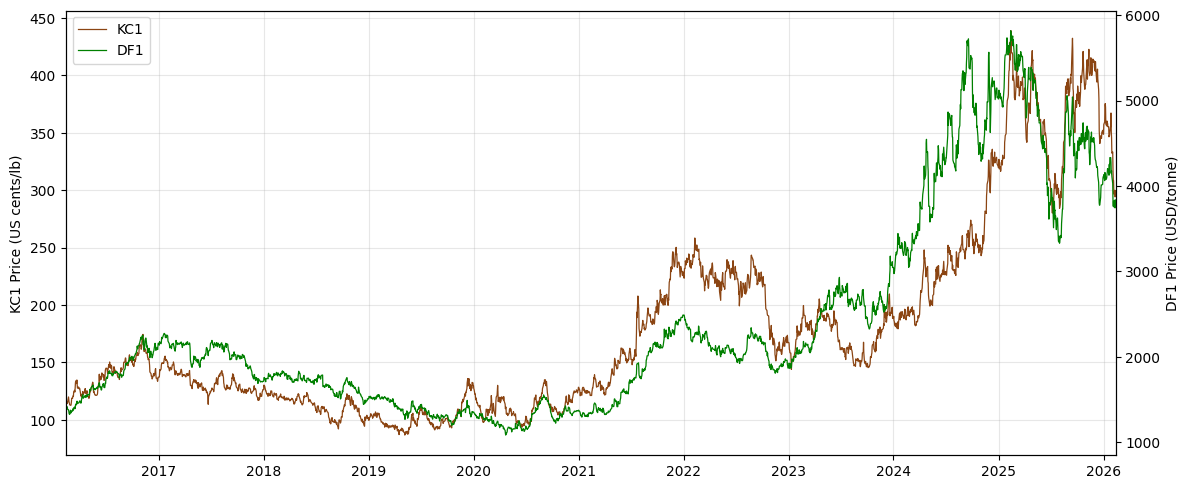

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(prices.index, prices["KC1"], color="saddlebrown", lw=.9, label="KC1")
ax1.set_ylabel("KC1 Price (US cents/lb)")
ax2.plot(prices.index, prices["DF1"], color="green", lw=.9, label="DF1")
ax2.set_ylabel("DF1 Price (USD/tonne)")

ax1.set_xlim([pd.to_datetime('2016-02-12'), pd.to_datetime('2026-02-12')])
ax1.grid(alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

#fig.suptitle("Arabica vs. Robusta front-month Futures Prices")
plt.tight_layout(); plt.show()

## 3. Log-prices and the walk-forward fold structure

**How the backtest is actually run.** A **rolling walk-forward**: each fold
estimates every parameter (thresholds, mean-reversion speed, expected
returns, covariances) on a fixed-length 4-year **calibration window**, then
trades the following 12 months **out-of-sample**; the window then slides
forward by one test window, dropping the oldest year. A 1-month **embargo**
separates each calibration window from its test window, and positions are
force-closed at fold boundaries. Only the stitched OOS folds are ever
reported. In the chart, each dotted box is one fold's calibration window
and the solid segment at the same height is the OOS window it trades.

**Why rolling rather than expanding?** The sample splits into structurally
different regimes — range-bound 2016–2019, supply-shock trends from 2021
onwards. An expanding (anchored) window mixes these regimes and lets stale
early-regime threshold economics dominate every later calibration, which is
exactly the regime-mismatch failure diagnosed in the original single-split
study. A rolling window keeps the estimation sample representative of
current dynamics and its size constant across folds (comparable estimation
error). The honest trade-off: fewer observations per calibration means
noisier estimates — mitigated by selecting the plateau of the threshold
grid rather than its argmax.

Screening window: 2016-02-12 -> 2019-12-24 (1008 obs)


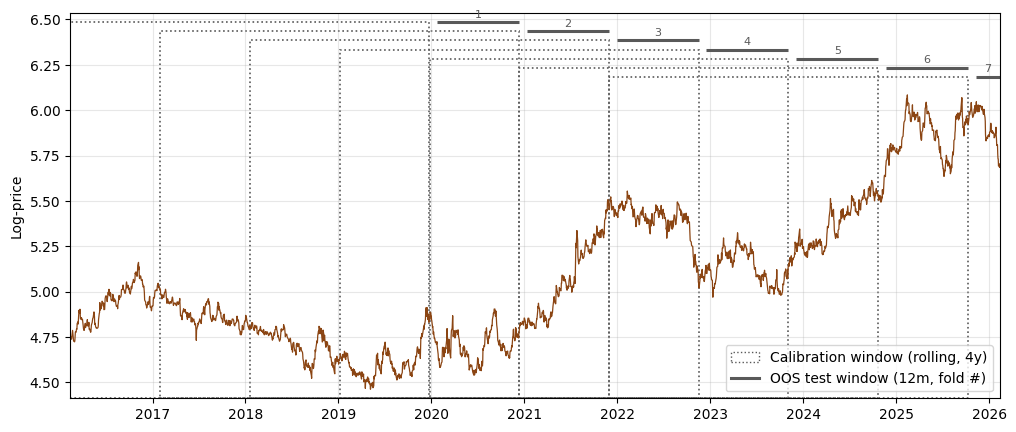

In [19]:
log_prices = data.to_log_prices(prices)
log_screen = data.screening_window(log_prices, WF["calibration_years"])
print(f"Screening window: {log_screen.index[0].date()} -> "
      f"{log_screen.index[-1].date()} ({len(log_screen)} obs)")

folds = walk_forward.walk_forward_folds(
    log_prices.index,
    calibration_size=int(WF["calibration_years"] * 252),
    test_size=WF["test_months"] * 21,
    embargo=WF["embargo_days"],
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(log_prices[ANCHOR], color="saddlebrown", lw=.9)
ax.set_xlim([pd.to_datetime('2016-02-12'), pd.to_datetime('2026-02-12')])
y0 = log_prices[ANCHOR].min() - 0.05
y1 = log_prices[ANCHOR].max() + 0.45 
ax.set_ylim(y0, y1)

grey = "0.35"
for k, (cal_idx, test_idx) in enumerate(folds):
    xl, xr = mdates.date2num(cal_idx[0]), mdates.date2num(cal_idx[-1])
    top = y1 - 0.05 - 0.05 * k
    ax.add_patch(Rectangle((xl, y0), xr - xl, top - y0, fill=False, edgecolor=grey, ls=":", lw=1.2))
    ax.plot([mdates.date2num(test_idx[0]), mdates.date2num(test_idx[-1])],
            [top, top], color=grey, lw=2.2, solid_capstyle="butt")
    ax.text(mdates.date2num(test_idx[len(test_idx) // 2]), top + 0.015,
            f"{k+1}", ha="center", va="bottom", fontsize=8, color=grey)
ax.add_patch(Rectangle((0, 0), 0, 0, fill=False, edgecolor=grey, ls=":", label="Calibration window (rolling, 4y)"))
ax.plot([], [], color=grey, lw=2.2, label="OOS test window (12m, fold #)")
ax.set_ylabel("Log-price"); ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.show()

## 4. ADF unit-root screening

In [6]:
exclude = set(cfg["universe"]["exclude"]) | {ANCHOR}
adf_results = stat_tests.adf_screen(log_screen, exclude=exclude)
adf_results.round(4)

,asset,n_obs,adf_stat,p_value
0,JVA,1008,-3.6836,0.0044
1,QSR,1008,-2.9370,0.0412
2,SJM,1008,-1.7326,0.4144
3,MDLZ,1008,-1.3863,0.5888
4,KDP,1008,-1.2552,0.6494
5,KO,1008,-0.9466,0.7722
6,MCD,1008,-0.9450,0.7728
7,NSGRY,1008,-0.4728,0.8972
8,SBUX,1008,-0.2686,0.9298
9,FARM,1008,-0.1634,0.9427


High p-values fail to reject the unit root: the series are I(1), as required.
A *stationary* price series would already be mean-reverting on its own and
admit no long-run equilibrium relationship to trade.

## 5. Engle-Granger cointegration against KC1

In [7]:
# NOTE: p-values here are computed on the first 4-year calibration window
# (2016-2019), not on the report's 7-year in-sample window (2016-2023).
# Several names look "cointegrated" on this shorter, calmer window (see the
# markdown below for why this is NOT robust evidence of cointegration).
eg_results = stat_tests.engle_granger_screen(log_screen, ANCHOR, exclude=exclude)
display(eg_results.round(4))

summary = stat_tests.summary_table(log_screen, ANCHOR, adf_results, eg_results)
summary.round(4)

,asset,n_obs,beta,alpha,r_squared,p_value,cointegrated
0,MCD,1008,-0.6450,8.0412,0.6585,0.0230,True
1,KDP,1008,0.1832,4.0342,0.5630,0.0457,True
2,QSR,1008,-0.4929,6.7707,0.3303,0.0493,True
3,SJM,1008,0.8660,0.6434,0.3891,0.1002,False
4,KO,1008,-1.3205,9.8367,0.4282,0.1290,False
5,NSGRY,1008,-0.8245,8.4344,0.4331,0.1981,False
6,NESN,1008,-0.8322,8.4561,0.4540,0.2096,False
7,FARM,1008,0.3788,3.5413,0.4888,0.2558,False
8,SBUX,1008,-0.5523,7.0642,0.3746,0.2689,False
9,MDLZ,1008,-0.7508,7.6385,0.2142,0.2905,False


,n_obs,mean,std,skew,kurtosis,corr_with_target,adf_p_value,eg_p_value
MCD,1008,5.0523,0.1928,-0.1383,-1.1242,-0.8115,0.7728,0.0230
KDP,1008,4.0839,0.6276,-0.4637,-1.6696,0.7504,0.6494,0.0457
QSR,1008,4.0339,0.1787,-0.7727,0.0076,-0.5747,0.0412,0.0493
SJM,1008,4.7797,0.1104,0.2353,-0.6203,0.6238,0.4144,0.1002
KO,1008,3.8277,0.0759,0.7901,-0.0286,-0.6544,0.7722,0.1290
NSGRY,1008,4.4296,0.1223,0.7241,-0.2513,-0.6581,0.8972,0.1981
NESN,1008,4.4147,0.1241,0.8221,-0.3192,-0.6738,0.9484,0.2096
FARM,1008,3.2768,0.2828,-1.2825,0.6141,0.6991,0.9427,0.2558
SBUX,1008,4.1315,0.1698,1.2155,0.2656,-0.6120,0.9298,0.2689
MDLZ,1008,3.8039,0.0945,0.9807,-0.0473,-0.4629,0.5888,0.2905


### Why are these p-values lower than in the report?

On this 4-year window (2016–2019) three names — MCD, KDP, QSR — show
Engle-Granger p-values below 0.05, in apparent contrast with the report,
where on the 7-year window (2016–2023) only SJM was significant. This is
**not** newly-discovered cointegration; three effects explain it:

1. **A corporate-action artifact (KDP).** On 2018-07-09 the Keurig–Dr Pepper
   Snapple merger closed and DPS holders received a **$103.75/share special
   cash dividend**; Bloomberg's `KDP` back-history chains the old DPS series
   *unadjusted*, so the series drops from 123.66 to 22.19 overnight (−82%),
   consistent with the dividend amount (the small residual is that day's
   market move). The series is not economically continuous,
   and a level break of that size invalidates the cointegration test for it.
2. **Window dependence and low test power.** The Engle-Granger test is known
   to be sensitive to the sample: on the calm, range-bound 2016–2019 coffee
   regime several staples track KC1 well enough to look cointegrated, but on
   the longer window the same names rise to p = 0.44–0.53. A relationship
   that only holds on a subwindow is a regime, not a long-run equilibrium —
   which is precisely the property pairs trading needs.
3. **Economically inverted relationships.** MCD "cointegrates" with a
   correlation of −0.81: statistically admissible, but a negative long-run
   relationship is not the co-movement a spread strategy wants to trade.

The basket therefore remains the one selected in the original study
(SJM, KO, MDLZ, JVA), and the conclusion of the report stands on the full
sample: evidence of cointegration within the assigned equity universe is
weak — the structural limitation of the exercise, imposed by the universe
rather than the methodology. Large consumer-staples companies pass coffee
input costs through to consumers, severing the long-run link between their
equity prices and the commodity. A more natural cointegrated pair would be
Arabica vs. Robusta (`KC1`/`DF1`), linked by substitution in roasters'
blends — listed as the first extension in the README.

## 6. Visual check of the equity basket

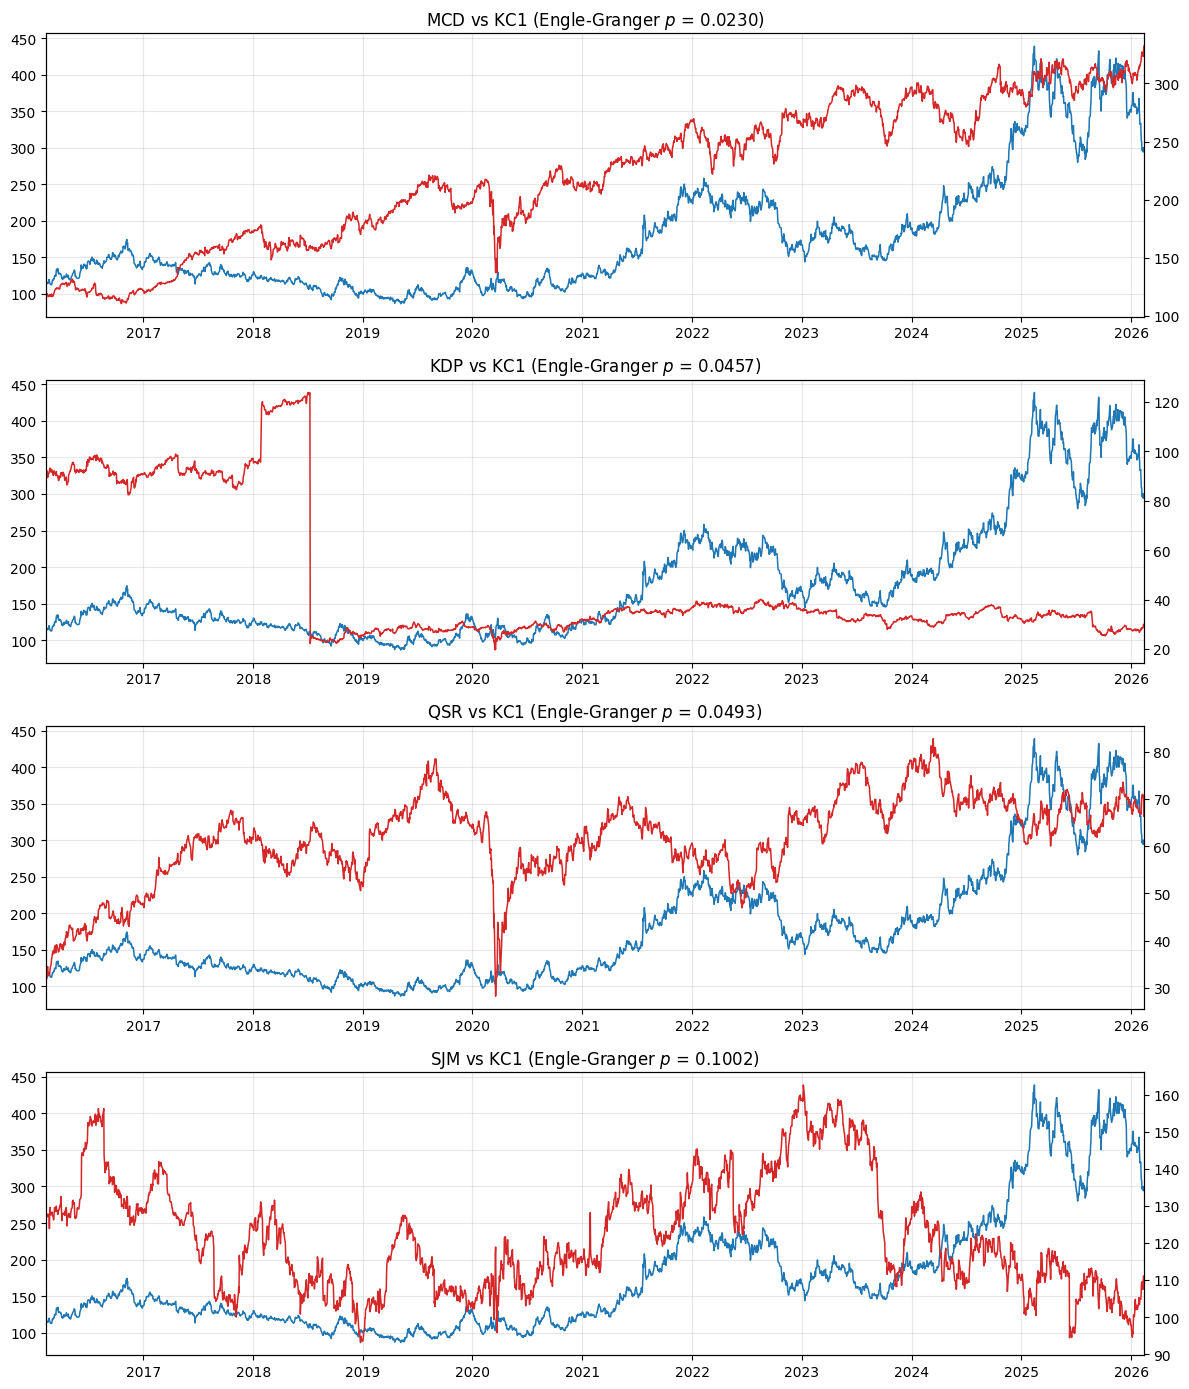

In [8]:
top4 = eg_results.head(4)["asset"].tolist()
fig, axes = plt.subplots(len(top4), 1, figsize=(12, 3.5 * len(top4)))
for ax, asset in zip(np.atleast_1d(axes), top4):
    pair = pd.concat([prices[ANCHOR], prices[asset]], axis=1).dropna()
    ax2 = ax.twinx()
    ax.plot(pair.index, pair[ANCHOR], color="tab:blue", lw=1.1, label=ANCHOR)
    ax2.plot(pair.index, pair[asset], color="tab:red", lw=1.1, label=asset)
    pval = eg_results.loc[eg_results["asset"] == asset, "p_value"].iloc[0]
    ax.set_title(f"{asset} vs {ANCHOR} (Engle-Granger $p$ = {pval:.4f})")
    ax.grid(alpha=0.3)
    ax.set_xlim([pd.to_datetime('2016-02-12'), pd.to_datetime('2026-02-12')])
plt.tight_layout(); plt.show()